## Time to get your hands dirty.  The transient Universe

*(exam guidelines available [here](https://github.com/dgerosa/astrostatistics_bicocca_2026/blob/main/exams.md))*



Let's go back to our previous example on the astrophysical transient.


8) Fit the same model from before with the same priors,  but this time use nested sampling.

$y = b$, for $t<t_0$

$y = b + A\exp[-\alpha(t-t_0)]$, for $t\geq t_0$

Be careful with how you transform your parameter space into a unit hypercube for the nested sampling priors (I used `ppf` from `scipy.stats.uniform`, but there are other ways to do it)

An appropriate check on whether you have done things correctly is that the posterior samples you get from the burst analysis here should give an equivalent corner plot to the MCMC you did earlier.

7) Another possible model that may explain the data is a Gaussian profile described by:

$y = b + A\exp[-(t-t_0)^2 / 2\sigma_W^2]$

Fit this model usign nested sampling and reasonable priors (this time is up to you to decide...)

9) Unlike MCMCs, nested sampling provides the Bayesian evidence. Compute the Bayesian evidence for this Gaussian model, and for the original burst model. Which model is the favored description of the data? Express this in terms of the Jeffrey's scale.

In [94]:
import numpy as np
import pylab as plt
from scipy.stats import norm, uniform
plt.rcParams['figure.figsize'] = [8, 8]
plt.rcParams['font.size'] = 12
import emcee
import scipy.stats
import corner

In [95]:
data= np.load('transient.npy')

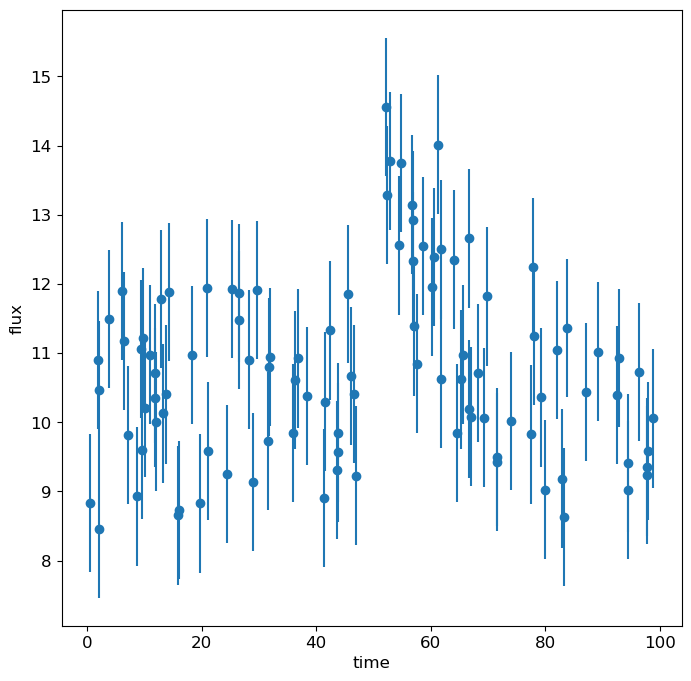

In [96]:
t,y,yerr=data.T
plt.errorbar(t,y,yerr=yerr,fmt='o')
plt.xlabel("time")
plt.ylabel("flux");

## Burst Model

In [124]:
def burst(theta,t):
    A,b,t0,alpha=theta 
    return np.where(t<t0,b,b+A*np.exp(-alpha*(t-t0)))

In [125]:
import dynesty
import numpy as np

# Define the dimensionality of our problem.
ndim = 4  # number of parameters in the model

In [126]:
def LogLikelihood(theta, data, model):
    x, y, sigma_y = data.T
    y_fit = model(theta, x)
    return -0.5 * np.sum((y-y_fit)**2 / sigma_y**2 )

In [127]:
# Define our uniform prior.
def ptform(u):
    x = np.empty_like(u)
    x[0] = uniform.ppf(u[0], loc=0, scale=50) #A
    x[1] = uniform.ppf(u[1], loc=0, scale=50) #b
    x[2] = uniform.ppf(u[2], loc=0, scale=100) #t0
    x[3] = uniform.ppf(u[3], loc=0, scale=1) #ln-alpha

    return x 

In [128]:
# "Static" nested sampling.
sampler = dynesty.NestedSampler(LogLikelihood, ptform, ndim, logl_args=(data, burst), sample='rwalk', nlive=500)
sampler.run_nested()
sresults = sampler.results

7727it [03:48, 33.84it/s, +500 | bound: 13 | nc: 1 | ncall: 160294 | eff(%):  5.149 | loglstar:   -inf < -48.754 <    inf | logz: -63.426 +/-  0.169 | dlogz:  0.001 >  0.509]


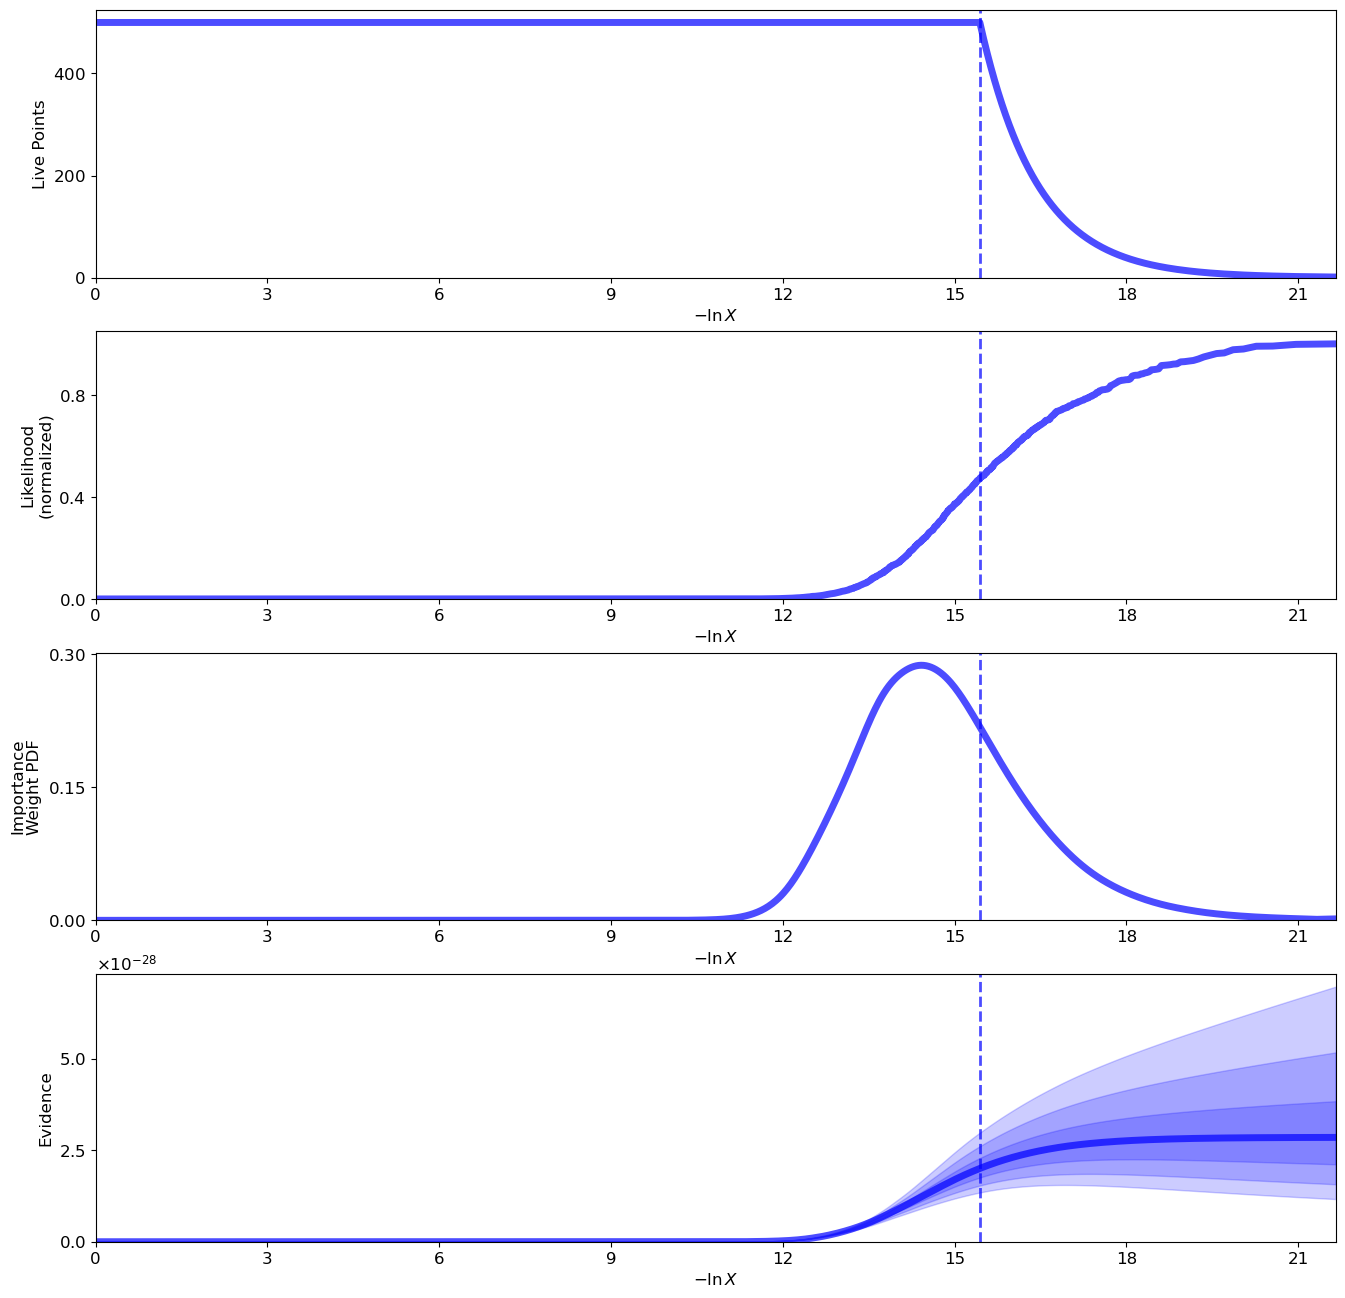

In [129]:
from dynesty import plotting as dyplot

# Plot a summary of the run.
rfig, raxes = dyplot.runplot(sresults)

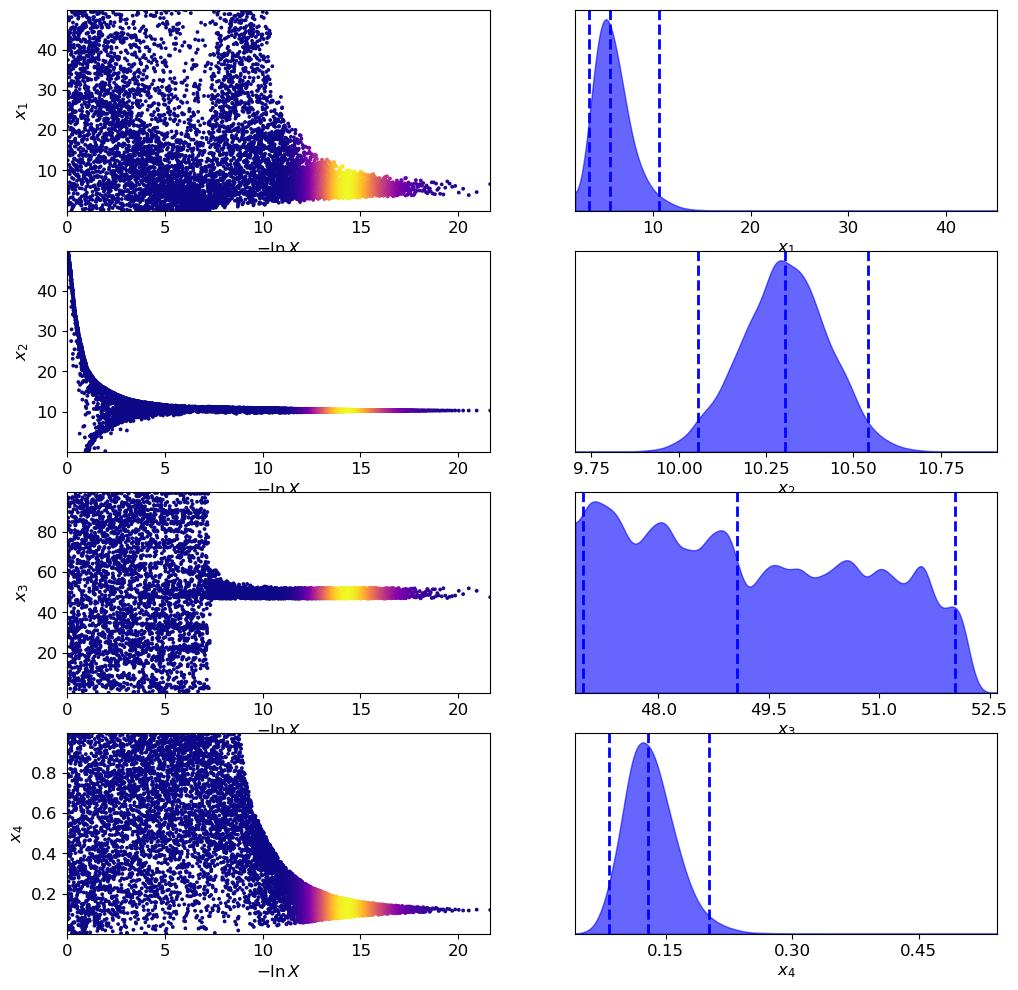

In [130]:
tfig, taxes = dyplot.traceplot(sresults)

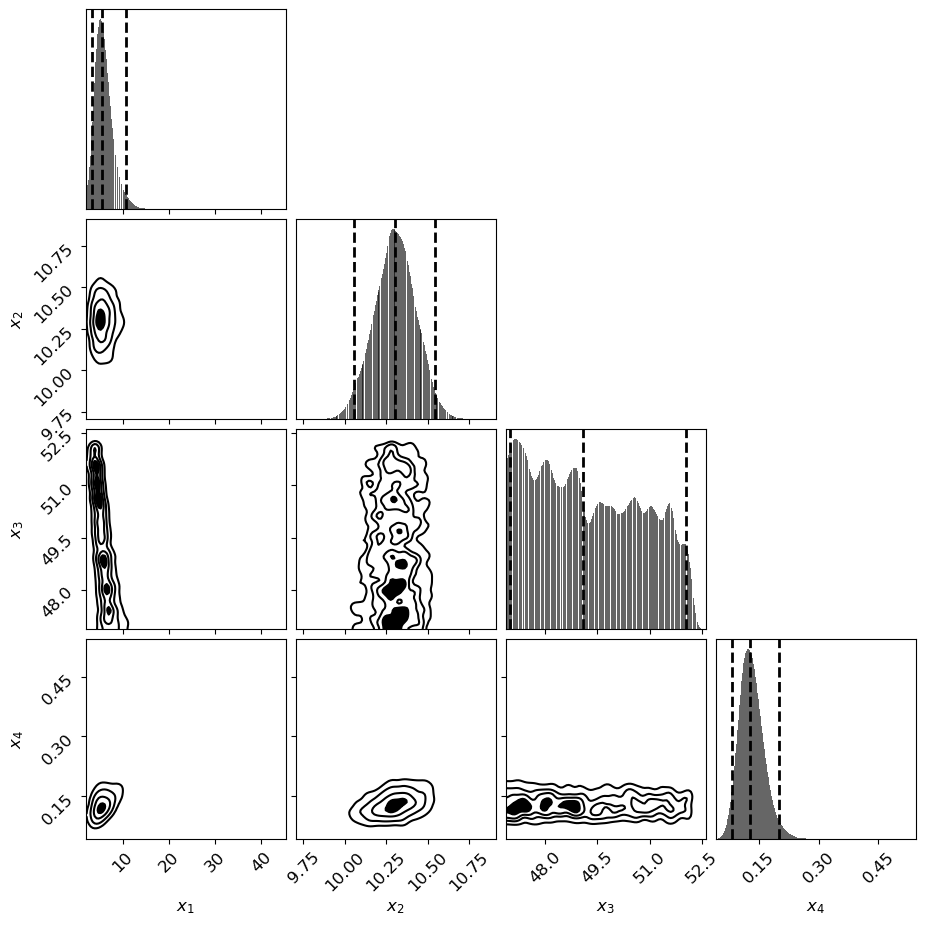

In [131]:
cfig, caxes = dyplot.cornerplot(sresults)

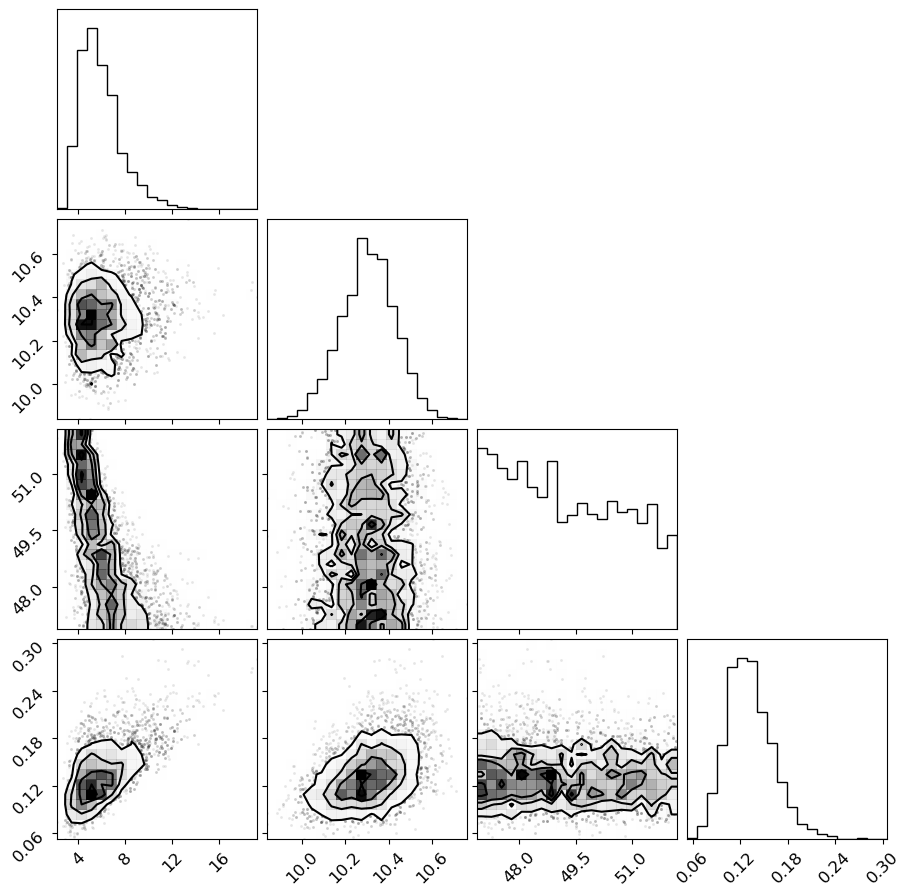

In [132]:
from dynesty import utils as dyfunc
# Resample weighted samples.
samples = sresults.samples  # samples
weights = np.exp(sresults.logwt - sresults.logz[-1])  # normalized weights

samples_equal = dyfunc.resample_equal(samples, weights)
import corner
corner.corner(samples_equal);

In [134]:
evidence_burst = sresults.logz[-1] #evidence
print("Bayesian evidence", np.exp(evidence_burst))

# Compute 10%-90% quantiles.
quantiles = [dyfunc.quantile(samps, [0.16, 0.84], weights=weights)
             for samps in samples.T]
print('68% parameter credible regions are: ' + '\n' + str(quantiles) + '\n')

# Compute weighted mean and covariance.
mean, cov = dyfunc.mean_and_cov(samples, weights)
print('Mean and covariance of parameters are: '+ '\n' + str(mean) + '\n' + str(cov))

Bayesian evidence 2.846713003618848e-28
68% parameter credible regions are: 
[[4.243481482303645, 7.4857780919091095], [10.179887660697306, 10.426001813907991], [47.48888806702236, 51.10375218208377], [0.1039195756145705, 0.15994985869683295]]

Mean and covariance of parameters are: 
[ 5.91485119 10.30332757 49.25979005  0.13203599]
[[ 3.38438394e+00  2.05373170e-02 -1.89611952e+00  3.25193970e-02]
 [ 2.05373170e-02  1.52956660e-02 -4.54268054e-03  1.51384804e-03]
 [-1.89611952e+00 -4.54268054e-03  2.36024303e+00 -1.77150695e-03]
 [ 3.25193970e-02  1.51384804e-03 -1.77150695e-03  9.04640066e-04]]


## Gaussian model

In [136]:
def gauss(theta,t):
    A,b,t0,sigma=theta 
    return b+A*np.exp(-(t-t0)**2/(2*sigma**2))

In [137]:
ndim = 4
# Define our uniform prior.
def ptform(u):
    x = np.empty_like(u)
    x[0] = uniform.ppf(u[0], loc=0, scale=10) #A
    x[1] = uniform.ppf(u[1], loc=0, scale=20) #b
    x[2] = uniform.ppf(u[2], loc=0, scale=100) #t0
    x[3] = uniform.ppf(u[3], loc=0, scale=10) #sigma

    return x 

In [138]:
# "Static" nested sampling.
sampler = dynesty.NestedSampler(LogLikelihood, ptform, ndim, logl_args=(data, gauss), sample='rwalk', nlive=500)
sampler.run_nested()
sresults = sampler.results

6473it [03:11, 33.74it/s, +500 | bound: 10 | nc: 1 | ncall: 130458 | eff(%):  5.366 | loglstar:   -inf < -52.445 <    inf | logz: -64.668 +/-  0.156 | dlogz:  0.001 >  0.509]


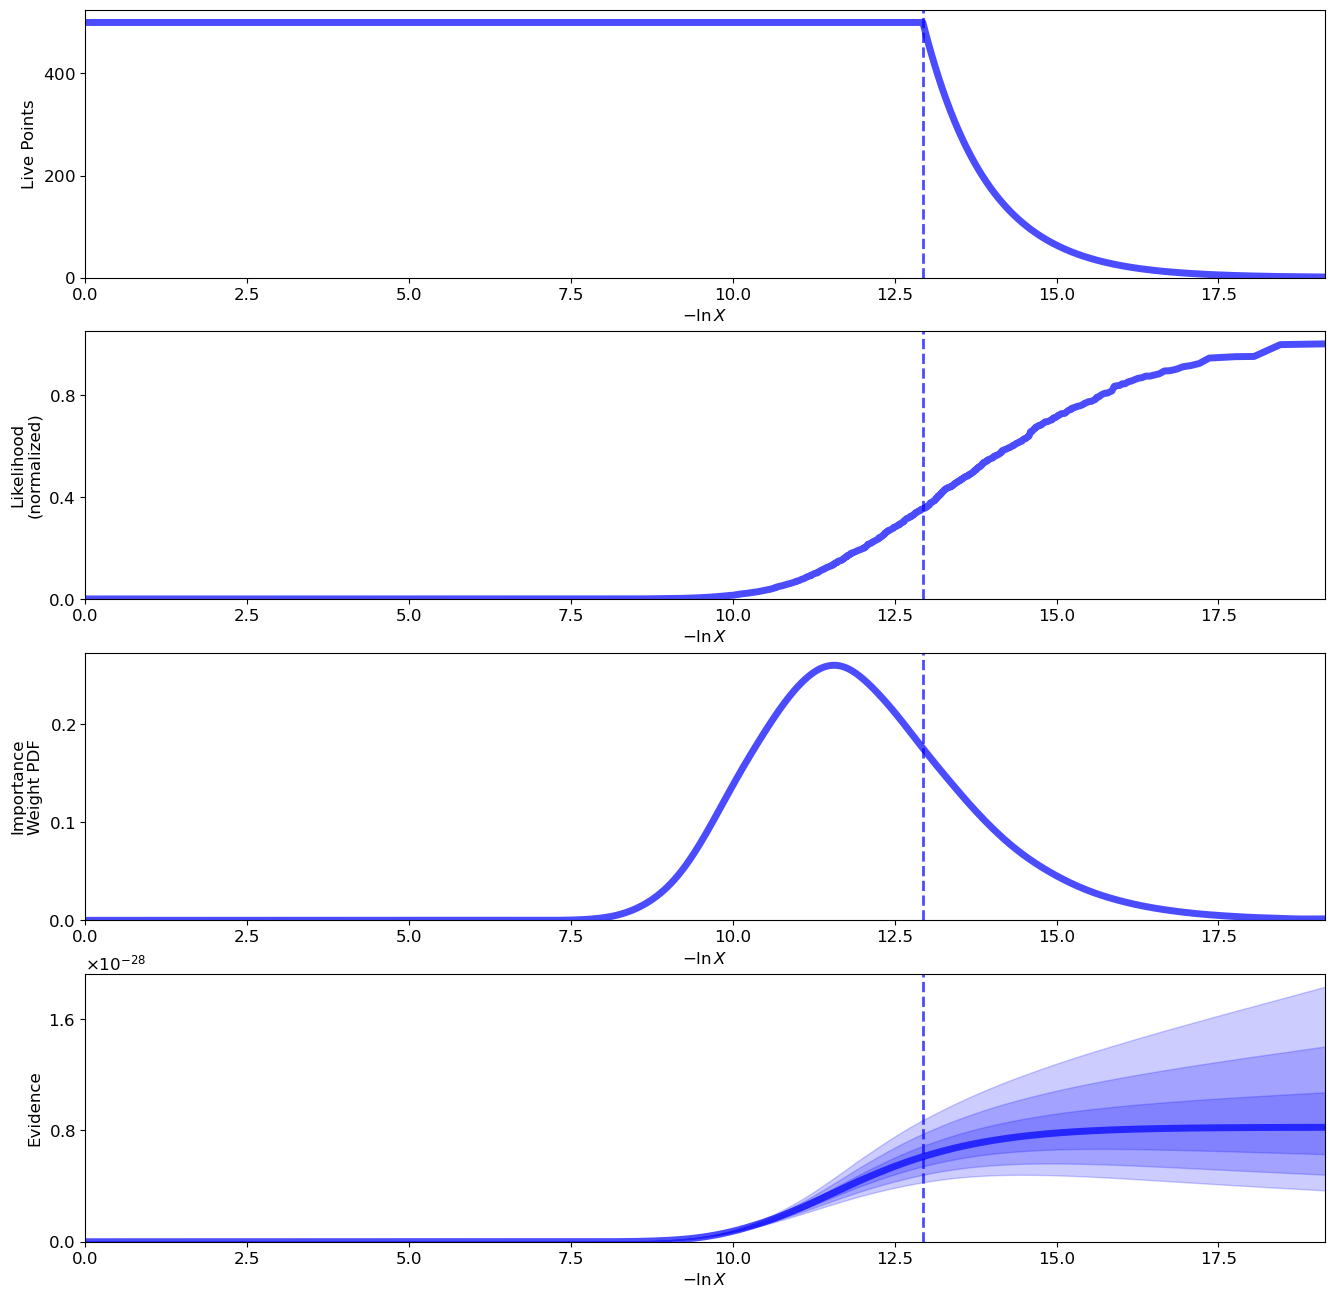

In [139]:
from dynesty import plotting as dyplot

# Plot a summary of the run.
rfig, raxes = dyplot.runplot(sresults)

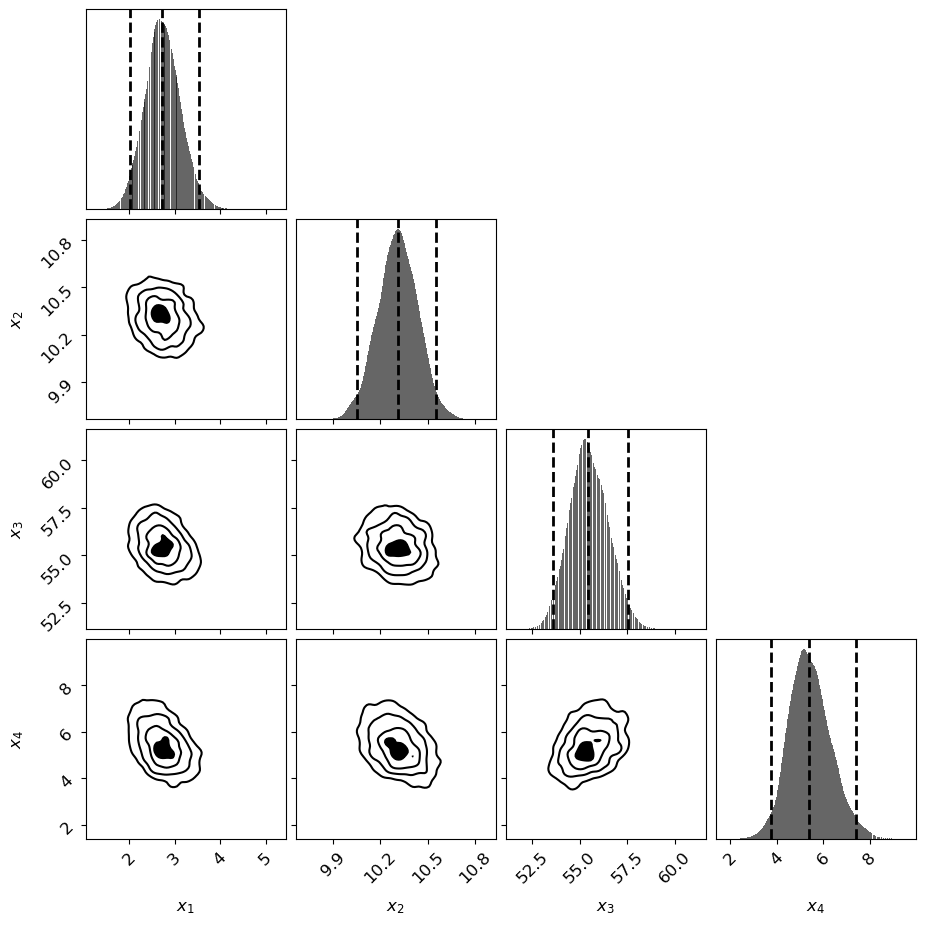

In [140]:
cfig, caxes = dyplot.cornerplot(sresults)

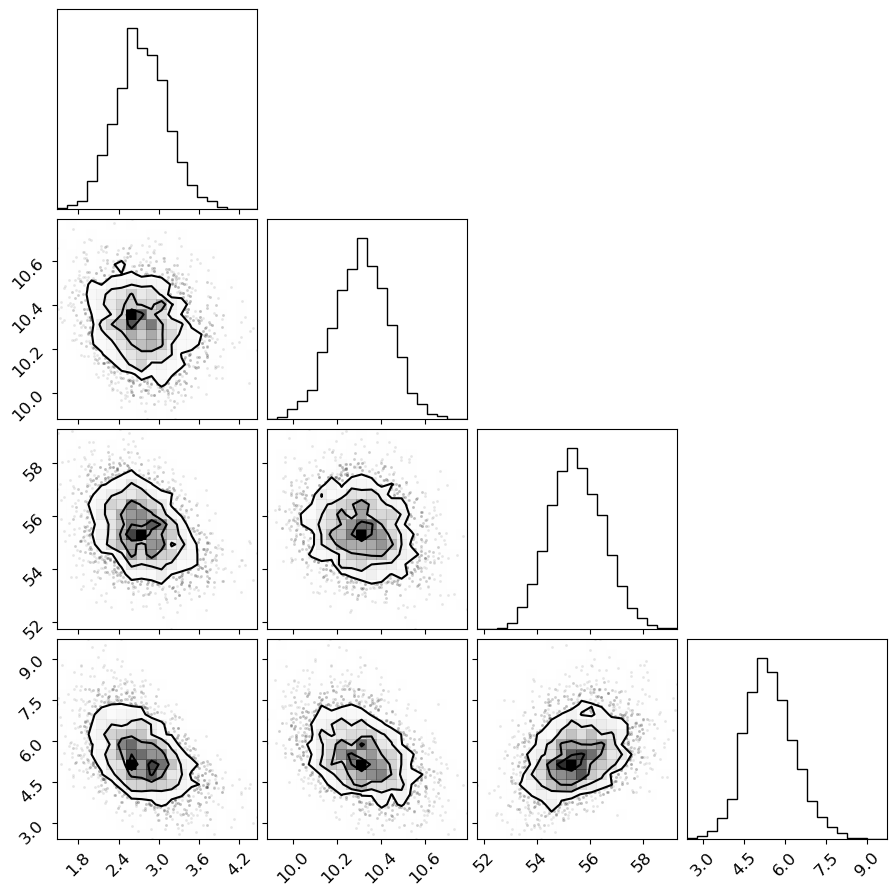

In [141]:
from dynesty import utils as dyfunc
# Resample weighted samples.
samples = sresults.samples  # samples
weights = np.exp(sresults.logwt - sresults.logz[-1])  # normalized weights

samples_equal = dyfunc.resample_equal(samples, weights)
import corner
corner.corner(samples_equal);

In [142]:
evidence_gauss = sresults.logz[-1] #evidence
print("Bayesian evidence", np.exp(evidence_gauss))

# Compute 10%-90% quantiles.
quantiles = [dyfunc.quantile(samps, [0.16, 0.84], weights=weights)
             for samps in samples.T]
print('68% parameter credible regions are: ' + '\n' + str(quantiles) + '\n')

# Compute weighted mean and covariance.
mean, cov = dyfunc.mean_and_cov(samples, weights)
print('Mean and covariance of parameters are: '+ '\n' + str(mean) + '\n' + str(cov))

Bayesian evidence 8.219492105374098e-29
68% parameter credible regions are: 
[[2.366774882404688, 3.115434590665825], [10.182347536636993, 10.435347832618422], [54.472377190460406, 56.491772869616945], [4.556040591278249, 6.338048055035888]]

Mean and covariance of parameters are: 
[ 2.74313971 10.30954792 55.48604119  5.43530313]
[[ 0.14968298 -0.01000608 -0.12349639 -0.15278687]
 [-0.01000608  0.01589507 -0.02247151 -0.04413394]
 [-0.12349639 -0.02247151  1.01484155  0.30265817]
 [-0.15278687 -0.04413394  0.30265817  0.83984526]]


# Bayesian Evidence

In [143]:
log_evidence = evidence_burst - evidence_gauss
print('Evidence: ', log_evidence)

Evidence:  1.2422416701200305


The burst model is 1.24x better than the gaussian model. On Jeffrey scale the strength of evidence is 'substantial'.